In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
def quad_function(x, a=False):
    return -(0.4 if a else 0.45) * x**2 + 10, 15, -35

def lin_function(x, a=False):
    return (0.5 if a else 0.3) * x, 10, -10

def cubic_function(x, a=False):
    return 3*x + x**3 * (0.2 if a else 0.02), 75, -75

def sin_function(x, a=False):
    return np.sin(x + (-2 if a else 0) ) * 5, 10, -10

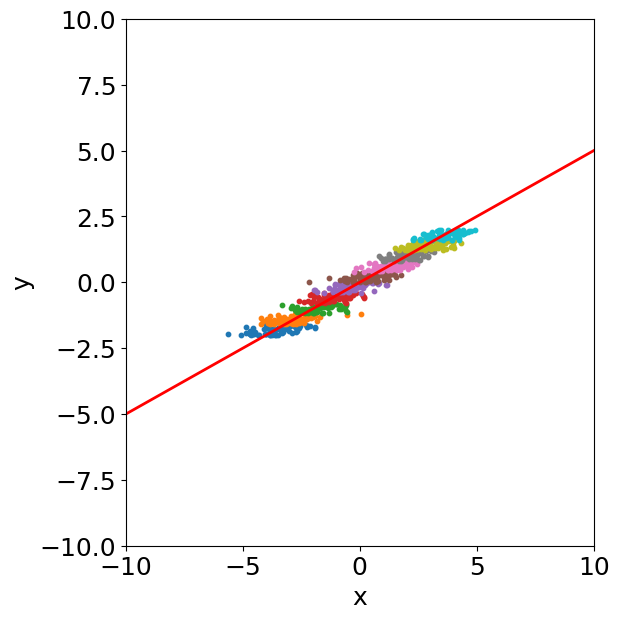

In [7]:
fig, ax = plt.subplots(figsize=(455/72.27, 455/72.27), dpi=100)

x_range = np.linspace(-10, 10, 200)

#dataset
a = True
dataset = "lin"
y, ylim1, ylim2 = lin_function(x_range, a=a)

df = pd.read_csv(f"../data/{dataset}.csv")

ax.plot(x_range, y, "red", linewidth=2)

train_data = df[(df["split"] == "train") & (df["a"] == (1 if a else 0))]

colors = plt.cm.tab10(np.linspace(0, 1, 10))
for domain_id in sorted(train_data["domain_id"].unique()):
    domain_data = train_data[train_data["domain_id"] == domain_id]
    ax.scatter(domain_data["X_obs"], domain_data["y"], 
               c=[colors[domain_id]], alpha=1, s=10)

font = 18

ax.set_xlabel("x", fontsize=font)
ax.set_ylabel("y", fontsize=font)
ax.tick_params(axis="both", which="major", labelsize=font)
ax.set_xlim(-10, 10)
ax.set_ylim(ylim2, ylim1)

plt.tight_layout()

plt.savefig(f"images/{dataset}_a={a}_environment.png", dpi=600, bbox_inches="tight")
plt.show()

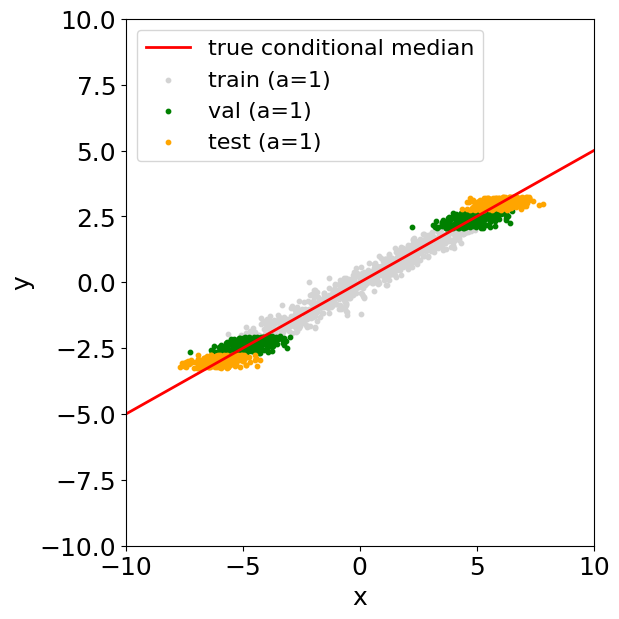

In [9]:
fig, ax = plt.subplots(figsize=(455/72.27, 455/72.27), dpi=100)

x_range = np.linspace(-10, 10, 200)

# data
a = True

dataset = "lin"
y, ylim1, ylim2 = lin_function(x_range, a=a)

df = pd.read_csv(f"../data/{dataset}.csv")

ax.plot(x_range, y, "red", linewidth=2, label="true conditional median")

train_data = df[(df["split"] == "train") & (df["a"] == (1 if a else 0))]
val_data = df[(df["split"] == "val") & (df["a"] == (1 if a else 0))]
test_data = df[(df["split"] == "test") & (df["a"] == (1 if a else 0))]

ax.scatter(train_data["X_obs"], train_data["y"], c="lightgray", alpha=1, s=10, label=f"train (a={1 if a else 0})")
ax.scatter(val_data["X_obs"], val_data["y"], c="green", alpha=1, s=10, label=f"val (a={1 if a else 0})")
ax.scatter(test_data["X_obs"], test_data["y"], c="orange", alpha=1, s=10, label=f"test (a={1 if a else 0})")

font = 18

ax.set_xlabel("x", fontsize=font)
ax.set_ylabel("y", fontsize=font)
ax.legend(fontsize=16)
ax.tick_params(axis="both", which="major", labelsize=font)
ax.set_xlim(-10, 10)
ax.set_ylim(ylim2, ylim1)

plt.tight_layout()

plt.savefig(f"images/{dataset}_a={a}_distribution.png", dpi=600, bbox_inches="tight")
plt.show()

# Model Evaluation

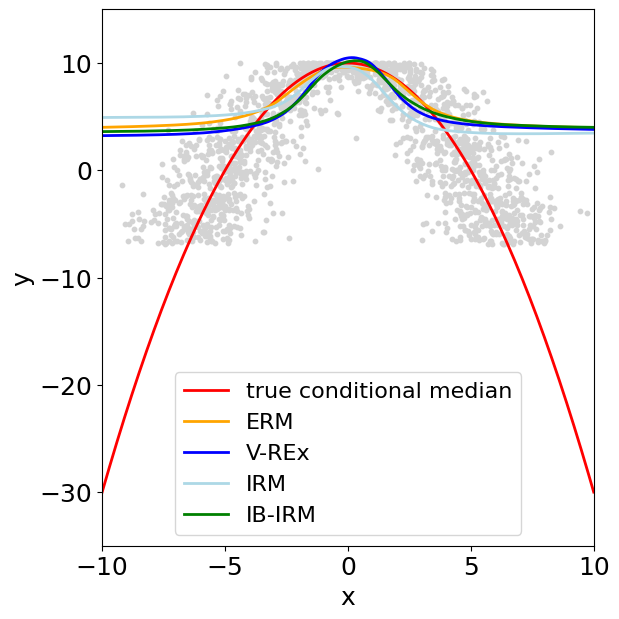

In [13]:
fig, ax = plt.subplots(figsize=(455/72.27, 455/72.27), dpi=100)

x_range = np.linspace(-10, 10, 200)

# data
a = True

dataset = "quad"
y, ylim1, ylim2 = quad_function(x_range, a=a)

df = pd.read_csv(f"../data/{dataset}.csv")

train_data = df[(df["split"] == "train") & (df["a"] == (1 if a else 0))]
val_data = df[(df["split"] == "val") & (df["a"] == (1 if a else 0))]
test_data = df[(df["split"] == "test") & (df["a"] == (1 if a else 0))]

ax.plot(x_range, y, "red", linewidth=2, label="true conditional median")

ax.scatter(train_data["X_obs"], train_data["y"], c="lightgray", alpha=1, s=10)
ax.scatter(val_data["X_obs"], val_data["y"], c="lightgray", alpha=1, s=10)
ax.scatter(test_data["X_obs"], test_data["y"], c="lightgray", alpha=1, s=10)

df_erm = pd.read_csv(f"../artifacts/{dataset}-normal-significance/predictions.csv")
ax.plot(x_range, df_erm["Prediction"], "orange", linewidth=2, label="ERM")

df_rex = pd.read_csv(f"../artifacts/{dataset}-normal-rex-significance/predictions.csv")
ax.plot(x_range, df_rex["Prediction"], "blue", linewidth=2, label="V-REx")

df_irm = pd.read_csv(f"../artifacts/{dataset}-normal-irm-significance/predictions.csv")
ax.plot(x_range, df_irm["Prediction"], "lightblue", linewidth=2, label="IRM")

df_irm_ib = pd.read_csv(f"../artifacts/{dataset}-normal-irm-ib-significance/predictions.csv")
ax.plot(x_range, df_irm_ib["Prediction"], "green", linewidth=2, label="IB-IRM")


font = 18

ax.set_xlabel("x", fontsize=font)
ax.set_ylabel("y", fontsize=font)
ax.tick_params(axis="both", which="major", labelsize=font)
ax.set_xlim(-10, 10)
ax.set_ylim(ylim2, ylim1)
ax.legend(fontsize=16)
plt.tight_layout()

plt.savefig(f"images/{dataset}_a={a}_result.png", dpi=600, bbox_inches="tight")
plt.show()

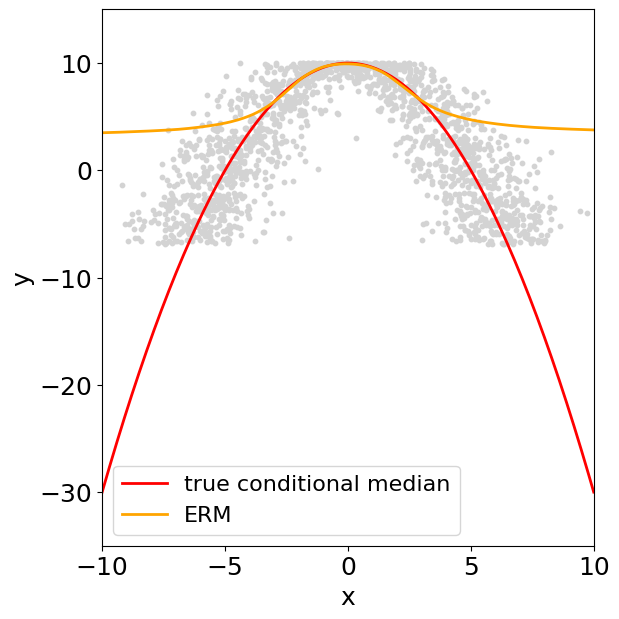

In [4]:
fig, ax = plt.subplots(figsize=(455/72.27, 455/72.27), dpi=100)

x_range = np.linspace(-10, 10, 200)

# data
a = True

dataset = "quad"
y, ylim1, ylim2 = quad_function(x_range, a=a)

df = pd.read_csv(f"../data/{dataset}.csv")

train_data = df[(df["split"] == "train") & (df["a"] == (1 if a else 0))]
val_data = df[(df["split"] == "val") & (df["a"] == (1 if a else 0))]
test_data = df[(df["split"] == "test") & (df["a"] == (1 if a else 0))]

ax.plot(x_range, y, "red", linewidth=2, label="true conditional median")

ax.scatter(train_data["X_obs"], train_data["y"], c="lightgray", alpha=1, s=10)
ax.scatter(val_data["X_obs"], val_data["y"], c="lightgray", alpha=1, s=10)
ax.scatter(test_data["X_obs"], test_data["y"], c="lightgray", alpha=1, s=10)

df_erm = pd.read_csv(f"../artifacts/{dataset}-normal-hyperparam-snake/predictions.csv")
ax.plot(x_range, df_erm["Prediction"], "orange", linewidth=2, label="ERM")

font = 18

ax.set_xlabel("x", fontsize=font)
ax.set_ylabel("y", fontsize=font)
ax.tick_params(axis="both", which="major", labelsize=font)
ax.set_xlim(-10, 10)
ax.set_ylim(ylim2, ylim1)
ax.legend(fontsize=16)
plt.tight_layout()

plt.show()